# 06 — The text-SC ridge estimator on the biweekly latent panel

**Their estimator, our validation.**

Wang, Liu, Zhang, Roth & Richardson, *Event Causality Identification with Synthetic
Control* ([arXiv:2509.18156](https://arxiv.org/abs/2509.18156)), §3.2, fit
synthetic-control weights on text embeddings by **unconstrained ridge regression**:

$$\min_{w}\;\Big\|u_{\text{study}}-\sum_j w_j u_j\Big\|^2\;+\;\lambda\sum_j w_j^2,
\qquad \lambda = 1.0\ \text{(set, not tuned)}$$

No simplex, no $\sum w = 1$, no non-negativity. That places it between the two
estimators this folder already runs:

| estimator | constraint | penalty | module |
|---|---|---|---|
| SCM (collaborator notebook 14) | $w\ge0$, $\sum w=1$ | none | `panel_scm.py` |
| **ridge (Wang et al.)** | **none** | $\lambda\|w\|^2$ toward $0$ | `panel_ridge.py` |
| ASCM (collaborator notebook 15) | $\sum w=1$, $w$ may go negative | ridge anchored at $w_{\text{SCM}}$ | `panel_ascm.py` |

### What their setup actually is

Read from the paper rather than the abstract: the donor pool is **2–5 documents**
(retrieve $n=100$, filter by a cosine ≥ 0.8 gate and a GPT-3.5 check), embeddings are
1536-d `text-embedding-ada-002`, and the pre-treatment side is a **single embedding
vector — $T_0 = 1$**. So they cannot hold out a pre-period, and never measure how well
the synthetic twin matches anything; evaluation is a downstream GPT-3.5 binary causality
judgment, scored as precision 0.2663 vs GPT-4's 0.2052 on COPES-hard.

Structurally that is *our* problem, not a larger one: they have 5 donors, we have 5;
they have 1 pre-period, we have 8. The difference is that we can score the counterfactual
and they cannot. This notebook runs their estimator through our P09/P10 holdout with
**the same donors, the same scaler, the same two schemes and the same flags** as SCM and
ASCM, so the comparison is measured rather than argued.

### Two details the paper leaves undetermined → four variants

1. **$\lambda = 1.0$ does not transport.** ada-002 vectors come back L2-normalized, so
   their loss is $O(1)$ and $\lambda=1$ is real shrinkage. Our design is 980 dims × 8
   periods of z-scored values (SSE ≈ 7,840), where a literal $\lambda=1$ is numerically
   indistinguishable from unregularized least squares. Both readings are run.
2. **The loss sums from $j=0$ while the penalty sums from $j=1$**, and the paper never
   says what $w_0$ is (its prose says "weights $w_1\dots w_J$"). Read here as an
   **unpenalized intercept** — independently interesting, since an unpenalized intercept
   is equivalent to the per-unit pre-period demeaning $\dot Y_{it,k}$ of Tian, Lee &
   Panchenko ([arXiv:2304.02272](https://arxiv.org/abs/2304.02272)).

| `variant` | preprocessing | $\lambda$ | intercept |
|---|---|---|---|
| `paper` | none | 1.0 fixed | no |
| `unitnorm` | L2-normalize each site × period z-scored 980-vector, average the per-period loss — restores the $O(1)$ single-period ada-002 loss scale so $\lambda=1$ means what it means in the paper | 1.0 fixed | no |
| `cv` | none | leave-one-fit-period-out CV over `logspace(-4,4,81)` (the ASCM grid) | no |
| `cv_intercept` | none | same CV | yes |

Weights are always **scored** on the standard z-scored design, never on a variant's
preprocessed one, so every number below is on one common scale.

### ⚠ The trap this notebook is built to avoid

`y` is z-scored against the **pooled** P01–P08 mean over all 60 sites, so $w\to0$ is the
pooled-mean predictor and its RMSPE is 1 *on average across sites* — but **per site it
scatters around 1**. Unconstrained ridge has an escape hatch SCM and ASCM do not: it can
shrink to that null instead of committing to a donor mix. A holdout RMSPE of 0.99
therefore proves nothing on its own. Every row below carries `null_rmse` (that site's own
$w=0$ score) and **`gain_over_null`**, which is the honest metric.

In [1]:
import sys, time
import numpy as np
import pandas as pd

sys.path.insert(0, ".")
import panel_lib as pl
import panel_scm as ps
import panel_ascm as pa
import panel_ridge as pr

pl.set_plot_style()
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)

PANELS = {"genfill":  ("latents_biweekly_genfill.npz", "panel_genfill_"),
          "chipmean": ("latents_biweekly.npz",         "panel_")}

P, DON, DONORS = {}, {}, {}
for tag, (npz, _) in PANELS.items():
    P[tag] = pl.Panel.from_npz(pl.LATD / npz)
    DON[tag], DONORS[tag], _ne = pl.knn_donors(P[tag])
    print(f"{tag:9s} latents={len(P[tag].flat):5d}  D={P[tag].D}  "
          f"treated={len(P[tag].treatments)}  controls={len(P[tag].controls)}")
print("\nvariants:", pr.VARIANTS, " paper lambda =", pr.PAPER_LAMBDA)

genfill   latents= 2357  D=980  treated=10  controls=50


chipmean  latents= 2322  D=980  treated=10  controls=50

variants: ('paper', 'unitnorm', 'cv', 'cv_intercept')  paper lambda = 1.0


## 1. Analytic gates on the estimator

No prior ridge run exists, so the parity-against-committed-CSVs gate used in notebook 05
does not apply. Three analytic identities stand in for it.

In [2]:
from scipy.optimize import minimize

panel = P["genfill"]
tid = panel.treatments[0]
dl = DONORS["genfill"]["main"][("sentinel2", tid)]
seqs = panel.usable(tid, "sentinel2", pl.TRAIN8, dl)
y, X = panel.design(tid, "sentinel2", seqs, dl)

# gate 1 — lambda -> 0 reproduces unregularized least squares
w0, _ = pr.ridge_fit(y, X, 1e-10)
wls, *_ = np.linalg.lstsq(X, y, rcond=None)
g1 = float(np.abs(w0 - wls).max())

# gate 2 — lambda -> inf drives w to 0, i.e. to the pooled-mean predictor
wI, bI = pr.ridge_fit(y, X, 1e14)
g2w = float(np.linalg.norm(wI))
g2r = pr.rmse_with_b(panel, wI, bI, tid, "sentinel2", seqs, dl)
g2n = pr.null_rmse(panel, tid, "sentinel2", seqs, dl)

# gate 3 — the closed form solves the stated objective
lam = 3.7
obj = lambda w: float(((y - X @ w) ** 2).sum() + lam * (w ** 2).sum())
num = minimize(obj, np.zeros(len(dl)), method="L-BFGS-B",
               options={"ftol": 1e-18, "gtol": 1e-14, "maxiter": 50000})
wc, _ = pr.ridge_fit(y, X, lam)
g3 = float(np.abs(wc - num.x).max())

print(f"gate 1  lambda->0  == np.linalg.lstsq        max|diff| = {g1:.2e}")
print(f"gate 2  lambda->inf  ||w|| = {g2w:.2e}   RMSPE = {g2r:.6f}  "
      f"(this site's w=0 null = {g2n:.6f})")
print(f"gate 3  closed form == numerical optimizer   max|diff| = {g3:.2e}")
assert g1 < 1e-10 and g2w < 1e-6 and abs(g2r - g2n) < 1e-9 and g3 < 1e-7
print("\nall analytic gates passed")

gate 1  lambda->0  == np.linalg.lstsq        max|diff| = 3.22e-15
gate 2  lambda->inf  ||w|| = 3.76e-11   RMSPE = 1.001661  (this site's w=0 null = 1.001661)
gate 3  closed form == numerical optimizer   max|diff| = 4.55e-09

all analytic gates passed


## 2. Non-interference gates

`panel_ridge` imports `panel_lib` and shares the `Panel` class with `panel_scm` /
`panel_ascm`. These gates prove it changed nothing: SCM and ASCM re-run through the
modules must still reproduce the committed validation CSVs, and the kNN donors handed to
ridge must be the ones already on disk — the **estimator is the only thing that varies**.

In [3]:
NUM = ["train_rmse", "valid_rmse", "ratio"]
KEY = ["arm", "sensor", "treatment_site_id", "scheme", "eval_period"]
SCM, ASCM = {}, {}

for tag, (_npz, pre) in PANELS.items():
    panel, donors = P[tag], DONORS[tag]
    SCM[tag] = ps.run_scm(panel, donors)
    ASCM[tag] = pa.run_ascm(panel, donors, SCM[tag])
    for name, new, old in (("scm", SCM[tag]["validation"], pre + "scm_validation.csv"),
                           ("ascm", ASCM[tag]["validation"], pre + "ascm_validation.csv")):
        m = new.merge(pd.read_csv(old), on=KEY, suffixes=("_n", "_o"))
        d = max(float(np.nanmax(np.abs(m[c + "_n"] - m[c + "_o"]))) for c in NUM)
        assert d < 1e-8, (tag, name, d)
        print(f"{tag:9s} {name:5s} reproduces committed CSV   max|diff| = {d:.2e}"
              f"   ({len(m)} rows)")
    o = pd.read_csv(pre + "knn_donors.csv").query("arm == 'main'")
    mm = DON[tag].merge(o, on=["sensor", "treatment_site_id", "rank"],
                        suffixes=("_n", "_o"))
    same = bool((mm["counterfactual_site_id_n"] == mm["counterfactual_site_id_o"]).all())
    assert same and len(mm) == 100, (tag, len(mm))
    print(f"{tag:9s} kNN donors identical to committed CSV  ({len(mm)} rows)")

genfill   scm   reproduces committed CSV   max|diff| = 2.22e-16   (60 rows)
genfill   ascm  reproduces committed CSV   max|diff| = 4.44e-16   (60 rows)
genfill   kNN donors identical to committed CSV  (100 rows)


chipmean  scm   reproduces committed CSV   max|diff| = 2.22e-16   (60 rows)
chipmean  ascm  reproduces committed CSV   max|diff| = 6.66e-16   (60 rows)
chipmean  kNN donors identical to committed CSV  (100 rows)


## 3. Fit the ridge estimator

Four variants × 2 sensors × 10 treated sites × 2 fit windows, on both latent inputs.
Closed form throughout — no GPU, nothing re-encoded.

In [4]:
RIDGE, CMP = {}, {}
for tag, (_npz, pre) in PANELS.items():
    t0 = time.time()
    RIDGE[tag] = pr.run_ridge(P[tag], DONORS[tag])
    CMP[tag] = pr.compare_all(SCM[tag]["validation"], ASCM[tag]["validation"],
                              RIDGE[tag]["validation"])
    R = RIDGE[tag]
    R["weights"].to_csv(pre + "ridge_weights.csv", index=False)
    R["lambda_cv"].to_csv(pre + "ridge_lambda_cv.csv", index=False)
    R["validation"].to_csv(pre + "ridge_validation.csv", index=False)
    R["effects"].to_csv(pre + "ridge_effects.csv", index=False)
    CMP[tag].to_csv(pre + "three_way_comparison.csv", index=False)
    print(f"{tag:9s} {time.time()-t0:5.1f}s   weights {len(R['weights']):4d}   "
          f"validation {len(R['validation']):3d}   effects {len(R['effects']):4d}   "
          f"comparison {len(CMP[tag]):3d}")

genfill    10.6s   weights  800   validation 240   effects  800   comparison  60


chipmean    9.8s   weights  800   validation 240   effects  800   comparison  60


## 4. Does unconstrained ridge use the donors, or back away from them?

`sum_weights` is the diagnostic the simplex hides: SCM and ASCM are forced to $\sum w=1$,
ridge is free. A $\sum w$ near 0 means the estimator declined to use the donor pool.

In [5]:
w = RIDGE["genfill"]["weights"]
print("=== generation-fill panel: weight diagnostics (fit window P01-08) ===")
print(w.query("fit_window == 'P01-08'")
       .groupby(["variant", "sensor"])
       .agg(sum_weights=("sum_weights", "mean"),
            weight_l2=("weight_l2_norm", "mean"),
            largest_w=("largest_donor_weight", "mean"),
            n_negative=("n_negative_weights", "mean"),
            lam_median=("lambda", "median")).round(3))
print("\nchosen lambda, CV variants (grid spans 1e-4 .. 1e4):")
cvw = w.query("variant.str.startswith('cv')", engine="python")
print(cvw.groupby(["variant", "sensor"])["lambda"]
         .describe()[["min", "50%", "max"]].round(3))
print("\nfraction of CV fits landing on a grid boundary:",
      cvw.groupby("variant")["lambda_at_boundary"].mean().round(3).to_dict())

=== generation-fill panel: weight diagnostics (fit window P01-08) ===
                        sum_weights  weight_l2  largest_w  n_negative  lam_median
variant      sensor                                                              
cv           sentinel1        0.157      0.078      0.057         0.1     712.643
             sentinel2        0.638      0.374      0.305         0.1    1394.795
cv_intercept sentinel1        0.158      0.078      0.057         0.1     630.957
             sentinel2        0.645      0.378      0.307         0.1    1313.110
paper        sentinel1        0.169      0.083      0.061         0.1       1.000
             sentinel2        0.754      0.446      0.359         0.2       1.000
unitnorm     sentinel1        0.085      0.042      0.031         0.1       1.000
             sentinel2        0.498      0.259      0.191         0.0       1.000

chosen lambda, CV variants (grid spans 1e-4 .. 1e4):
                            min       50%      max
varia

## 5. Three-way comparison — and the null

`null_rmse` is each site's own $w=0$ score. Read the bars against the **black marker**,
not against the dashed line at 1.

=== genfill: mean holdout RMSPE, frozen_joint (w8 -> P09+P10 pooled) ===
sensor                         sentinel1  sentinel2
valid_rmse_scm                    1.0606     1.0503
valid_rmse_ascm                   1.0606     1.0503
valid_rmse_ridge_cv               0.9883     1.0076
valid_rmse_ridge_cv_intercept     0.9883     1.0048
valid_rmse_ridge_paper            0.9884     1.0223
valid_rmse_ridge_unitnorm         0.9888     0.9935
null_rmse                         0.9911     1.0182

=== chipmean: mean holdout RMSPE, frozen_joint (w8 -> P09+P10 pooled) ===
sensor                         sentinel1  sentinel2
valid_rmse_scm                    1.0583     1.1804
valid_rmse_ascm                   1.0583     1.1804
valid_rmse_ridge_cv               0.9874     1.1252
valid_rmse_ridge_cv_intercept     0.9870     1.1290
valid_rmse_ridge_paper            0.9874     1.1316
valid_rmse_ridge_unitnorm         0.9878     1.1139
null_rmse                         0.9901     1.1358



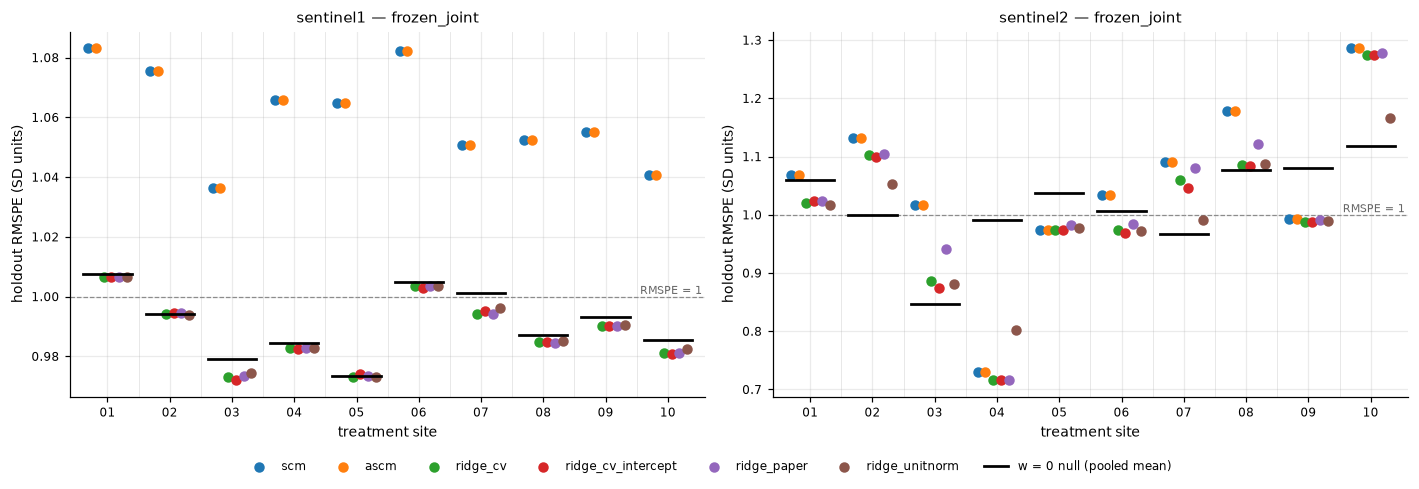

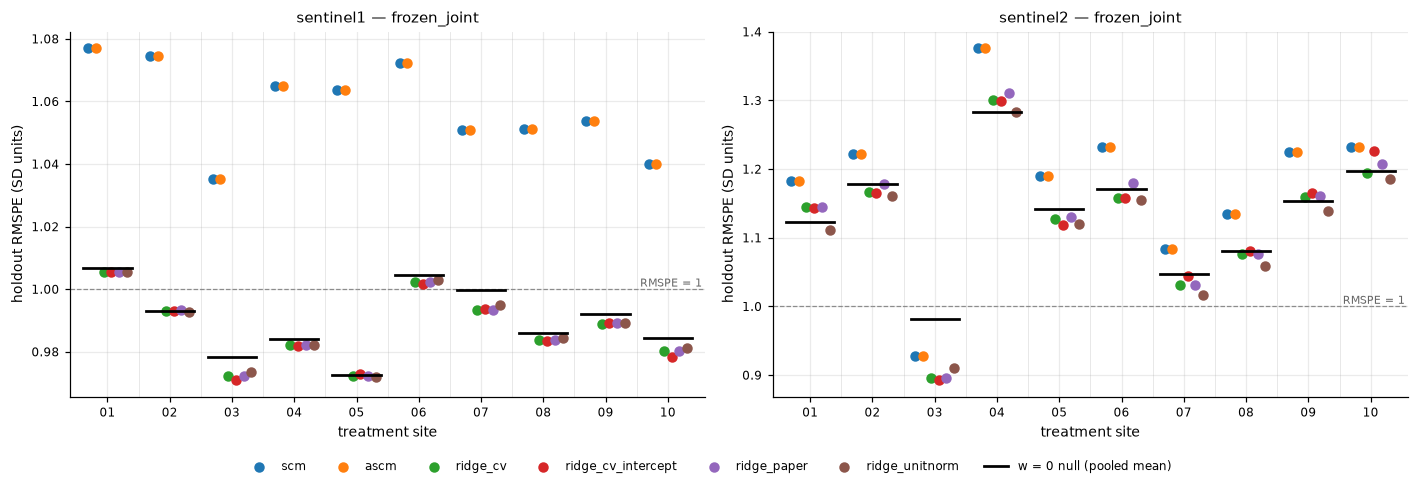

In [6]:
for tag, (_npz, pre) in PANELS.items():
    cols = [c for c in CMP[tag].columns if c.startswith("valid_rmse_")] + ["null_rmse"]
    print(f"=== {tag}: mean holdout RMSPE, frozen_joint (w8 -> P09+P10 pooled) ===")
    print(CMP[tag].query("scheme == 'frozen_joint'")
          .groupby("sensor")[cols].mean().round(4).T)
    print()

fig = pr.plot_three_way(CMP["genfill"], "panel_genfill_ridge_three_way.png")
_ = pr.plot_three_way(CMP["chipmean"], "panel_ridge_three_way.png")

## 6. `gain_over_null` — the honest metric

Positive means the estimator predicted something the pooled mean did not.

In [7]:
for tag in PANELS:
    g = RIDGE[tag]["validation"].dropna(subset=["gain_over_null"])
    print(f"=== {tag}: RMSPE gain over that site's own w=0 null ===")
    print(g.groupby(["variant", "sensor"])["gain_over_null"]
           .agg(["mean", "median", "max"]).round(4))
    print()

print("=== cells where the BEST of all six estimators beats that site's own null ===")
for tag in PANELS:
    b = CMP[tag].groupby(["sensor", "scheme"])["beats_null"].agg(["sum", "count"])
    print(f"-- {tag} --"); print(b); print()

print("best_method tally (genfill):",
      CMP["genfill"]["best_method"].value_counts().to_dict())
print("best_method tally (chipmean):",
      CMP["chipmean"]["best_method"].value_counts().to_dict())

=== genfill: RMSPE gain over that site's own w=0 null ===
                          mean  median     max
variant      sensor                           
cv           sentinel1  0.0028  0.0027  0.0082
             sentinel2  0.0161 -0.0008  0.3152
cv_intercept sentinel1  0.0029  0.0028  0.0093
             sentinel2  0.0193 -0.0016  0.3168
paper        sentinel1  0.0027  0.0027  0.0082
             sentinel2  0.0018 -0.0303  0.3234
unitnorm     sentinel1  0.0023  0.0020  0.0059
             sentinel2  0.0274 -0.0004  0.2462

=== chipmean: RMSPE gain over that site's own w=0 null ===
                          mean  median     max
variant      sensor                           
cv           sentinel1  0.0027  0.0029  0.0081
             sentinel2  0.0111  0.0037  0.1141
cv_intercept sentinel1  0.0031  0.0029  0.0094
             sentinel2  0.0072 -0.0002  0.1186
paper        sentinel1  0.0027  0.0028  0.0082
             sentinel2  0.0053 -0.0037  0.1145
unitnorm     sentinel1  0.0023  0.00

In [8]:
# where the S2 gains are concentrated: per-site, generation-fill, best ridge variant
s2 = (RIDGE["genfill"]["validation"]
      .query("sensor == 'sentinel2' and scheme == 'frozen_joint' "
             "and variant == 'unitnorm'")
      .sort_values("gain_over_null", ascending=False)
      [["treatment_site_id", "lambda", "sum_weights", "null_rmse",
        "valid_rmse", "gain_over_null", "flag_level"]])
print("sentinel2, frozen_joint, variant=unitnorm, generation-fill panel:")
print(s2.to_string(index=False, float_format=lambda v: f"{v:8.4f}"))

sentinel2, frozen_joint, variant=unitnorm, generation-fill panel:
treatment_site_id   lambda  sum_weights  null_rmse  valid_rmse  gain_over_null flag_level
   treatment_0004   1.0000       0.5592     0.9905      0.8027          0.1878       pass
   treatment_0009   1.0000       0.7137     1.0802      0.9890          0.0912       pass
   treatment_0005   1.0000       0.5016     1.0373      0.9766          0.0607       pass
   treatment_0001   1.0000       0.3637     1.0602      1.0167          0.0434       FAIL
   treatment_0006   1.0000       0.4391     1.0059      0.9728          0.0331       pass
   treatment_0008   1.0000       0.3807     1.0763      1.0870         -0.0106       FAIL
   treatment_0007   1.0000       0.3694     0.9671      0.9906         -0.0235       pass
   treatment_0003   1.0000       0.4637     0.8473      0.8808         -0.0334       pass
   treatment_0010   1.0000       0.5840     1.1173      1.1667         -0.0494       FAIL
   treatment_0002   1.0000       0

## Reading

### 1. Ridge beats SCM and ASCM — by declining to use the donors

On the generation-fill panel, frozen-joint holdout RMSPE: ridge **0.988** (S1) and
**0.994** (S2, `unitnorm`) against SCM/ASCM's **1.061** and **1.050**. Taken at face
value that is a large win, and `best_method` is a ridge variant in 58 of 60 cells.

It is not a win. `sum_weights` is **0.085–0.169** on S1 and **0.50–0.75** on S2 — the
estimator, once freed from $\sum w = 1$, throws most of the donor mix away. The CV
variants pick $\lambda$ with a median of **631** (S1) and **1,395** (S2) on a grid that
tops out at $10^4$. And that site's own $w=0$ null is **0.991** on S1, so ridge's 0.988
is a gain of **0.0023–0.0031 SD** — three thousandths. In the figure every S1 ridge dot
sits exactly on the black null rule.

**On S1 the ridge estimator has no predictive power. Its entire apparent advantage over
SCM is the freedom to shrink to the mean.**

### 2. The real finding: the simplex was actively hurting

SCM and ASCM score **1.06** where doing nothing scores **0.991**. $\sum w = 1$ forces
the estimator to commit to a donor mix that is *worse than the pooled mean*; ridge is
allowed to abstain and SCM is not. That sharpens notebooks 02/03: "latent-space SCM has
no held-out predictive power" understates it — the simplex constraint made it worse than
the null, and the null was never in the comparison until now.

### 3. S2 carries a little real signal — concentrated, not systematic

`unitnorm` on S2 has mean gain **+0.027** but median **−0.0004** and max **+0.246**: five
sites gain, five lose. The gainers are sites 04 (null 0.990 → 0.803, +0.188), 09 (+0.091),
05 (+0.061), 01 (+0.043), 06 (+0.033); 02, 03, 07, 08, 10 lose. Sites 04 and 05 are the
problem sites that generation fill improved in notebook 05. A 5-of-10 split is a coin
flip, so this is hypothesis-generating at most.

The cross-sensor contrast is the informative part: ridge will spend **half** a donor mix
on S2 and **a tenth** on S1. That matches the flat S1 kNN distances (12.66–13.28) — in
980-d, no member of the 50-control pool is near any treated S1 site, and the estimator
independently discovers it.

### 4. The paper's two undetermined details turn out to be immaterial here

- **$\lambda = 1.0$ literal ≡ CV on S1** (0.9884 vs 0.9883), confirming the prediction
  that at our scaling $\lambda=1$ is numerically negligible. On S2 it does matter, and
  the wrong way: `paper` (1.022) is worse than `cv` (1.008) and `unitnorm` (0.994), i.e.
  $\lambda = 1$ under-regularizes.
- **The intercept reading of $w_0$ changes essentially nothing** (`cv` 0.9883 vs
  `cv_intercept` 0.9883 on S1; 1.008 vs 1.005 on S2). Per-unit pre-period demeaning in
  the Tian–Lee–Panchenko sense does not rescue the fit either.
- `unitnorm` is the best variant overall (best in 20/60 cells on generation-fill, 26/60
  on chip-mean). Its only difference is per-period L2 normalization, which removes
  site-level magnitude — a crude version of the spatial pooling the projection direction
  proposes, and the one variant that helps S2.

### 5. Both latent inputs tell the same story

The chip-mean panel reproduces every conclusion; its S2 null is simply worse (1.136 vs
1.018), consistent with notebook 05's finding that generation fill widens the cross-site
latent spread.

### 6. What this settles about the comparison with Wang et al.

Their estimator is not why their pipeline works. Run on data where the counterfactual can
actually be scored, unconstrained ridge lands on the null. What their setting has and
ours does not is a **similarity-trained embedding plus a cosine ≥ 0.8 donor gate** — they
only ever fit weights over donors already known to be near-identical. Our kNN distances
say no member of the 50 is that close, and ridge's own shrinkage agrees.

### Caveat on `flag_level`

`flag_level` (pass iff RMSPE < 1) is leaky: **37 of 60** per-site nulls are already below
1, so an estimator can "pass" by predicting nothing. Quote `gain_over_null` alongside it,
never the flag on its own — this applies to the SCM and ASCM tables in notebooks 02, 03
and 05 as well.

### Follow-up not in this build

Abadie-style in-space placebo tests (fit each estimator to the 50 controls as
pseudo-treated) would turn `gain_over_null` into a permutation p-value, and would apply
to SCM and ASCM equally. Okano & Kurisu give the same construction for the functional
case ([arXiv:2601.07539](https://arxiv.org/abs/2601.07539)).